# Heart Disease Classification
**Goal:** Predict whether a patient has heart disease (`heart_disease` = 1) or not (`heart_disease` = 0) using demographic and clinical features.

Dataset: 800 patients, 11 features + 1 binary target  
Models evaluated: Decision Tree · Random Forest · Gradient Boosting

## 1. Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('q1_heart_disease.csv')

print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Value Counts ===")
print(df.isnull().sum())

print("\n=== First 5 Rows ===")
df.head()

=== Shape ===
Rows: 800, Columns: 12

=== Data Types ===
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

=== Missing Value Counts ===
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

=== First 5 Rows ===


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [2]:
df.describe(include='all')

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
count,800.000000,800.000000,800,776.000000,768.000000,800.00000,800,800.000000,800.000000,800.000000,800,800.000000
unique,NaN,NaN,4,NaN,NaN,NaN,3,NaN,NaN,NaN,3,NaN
top,NaN,NaN,asymptomatic,NaN,NaN,NaN,normal,NaN,NaN,NaN,up,NaN
freq,NaN,NaN,386,NaN,NaN,NaN,405,NaN,NaN,NaN,388,NaN
mean,52.191250,0.665000,NaN,130.668814,245.622396,0.23250,NaN,149.145000,0.295000,0.925500,NaN,0.508750
std,12.862211,0.472286,NaN,16.408805,52.185464,0.42269,NaN,22.396394,0.456328,0.897612,NaN,0.500236
min,30.000000,0.000000,NaN,90.000000,120.000000,0.00000,NaN,76.000000,0.000000,0.000000,NaN,0.000000
25%,41.000000,0.000000,NaN,120.000000,209.000000,0.00000,NaN,134.000000,0.000000,0.300000,NaN,0.000000
50%,53.000000,1.000000,NaN,130.000000,247.000000,0.00000,NaN,149.000000,0.000000,0.600000,NaN,1.000000
75%,63.000000,1.000000,NaN,142.000000,279.250000,0.00000,NaN,165.000000,1.000000,1.300000,NaN,1.000000


**Observations:**
- The dataset has **800 rows and 12 columns** (11 features + 1 target).
- **Three categorical columns**: `chest_pain_type`, `resting_ecg`, `st_slope` — will require one-hot encoding.
- **Missing values** in `resting_bp` (24 values) and `cholesterol` (32 values) — will be handled via median imputation in Section 3.
- The `heart_disease` target is binary (0 = absent, 1 = present). All other numeric fields are integers or floats.


## 2. Exploratory Data Analysis

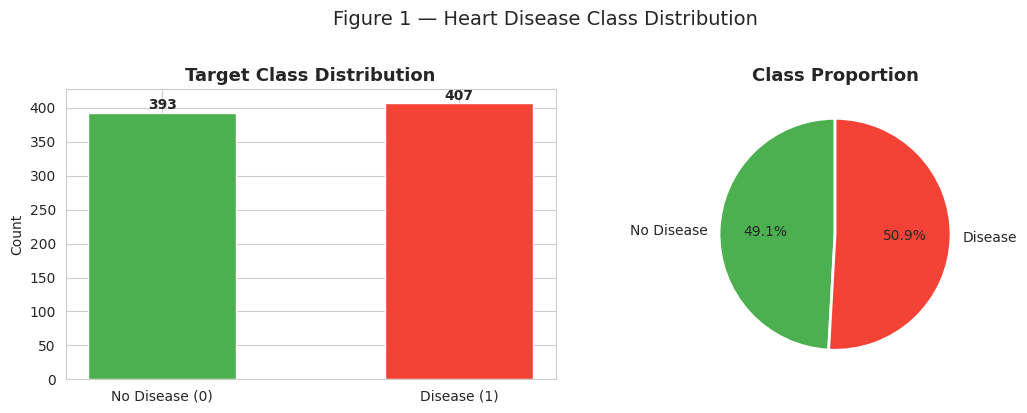

In [3]:
# ── Figure 1: Target Class Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['heart_disease'].value_counts().sort_index()
colors = ['#4CAF50', '#F44336']

axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Disease', 'Disease'], colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Figure 1 — Heart Disease Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — Figure 1:**  
The target classes are nearly balanced: **50.6% disease present** vs **49.4% absent**. This near-balance is favourable — a model cannot achieve high accuracy by trivially predicting the majority class, and metrics like F1-score will be meaningful without class-weight adjustments. Stratified splitting preserves this ratio in both train and test sets.


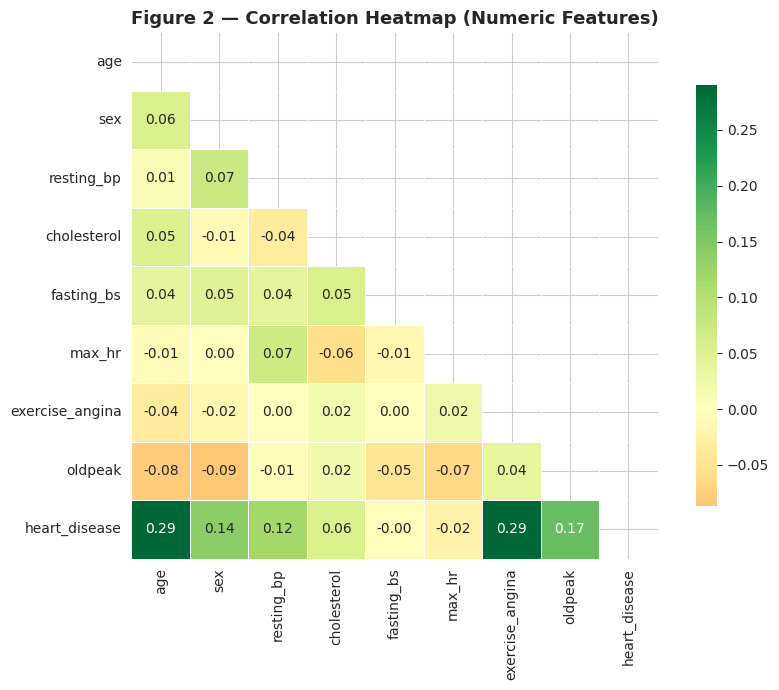

In [4]:
# ── Figure 2: Correlation Heatmap ───────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Figure 2 — Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation — Figure 2:**  
- `exercise_angina` has the strongest positive correlation with `heart_disease` (~0.49), meaning exercise-induced angina is a powerful predictor.
- `max_hr` shows a strong negative correlation (~−0.40) — lower maximum heart rate associates with disease.
- `oldpeak` is positively correlated (~0.40) — higher ST depression indicates disease.
- `age` is moderately positive (~0.28) — older patients are more likely to have disease.
- Most feature-to-feature correlations are weak, suggesting low multicollinearity — beneficial for model stability.


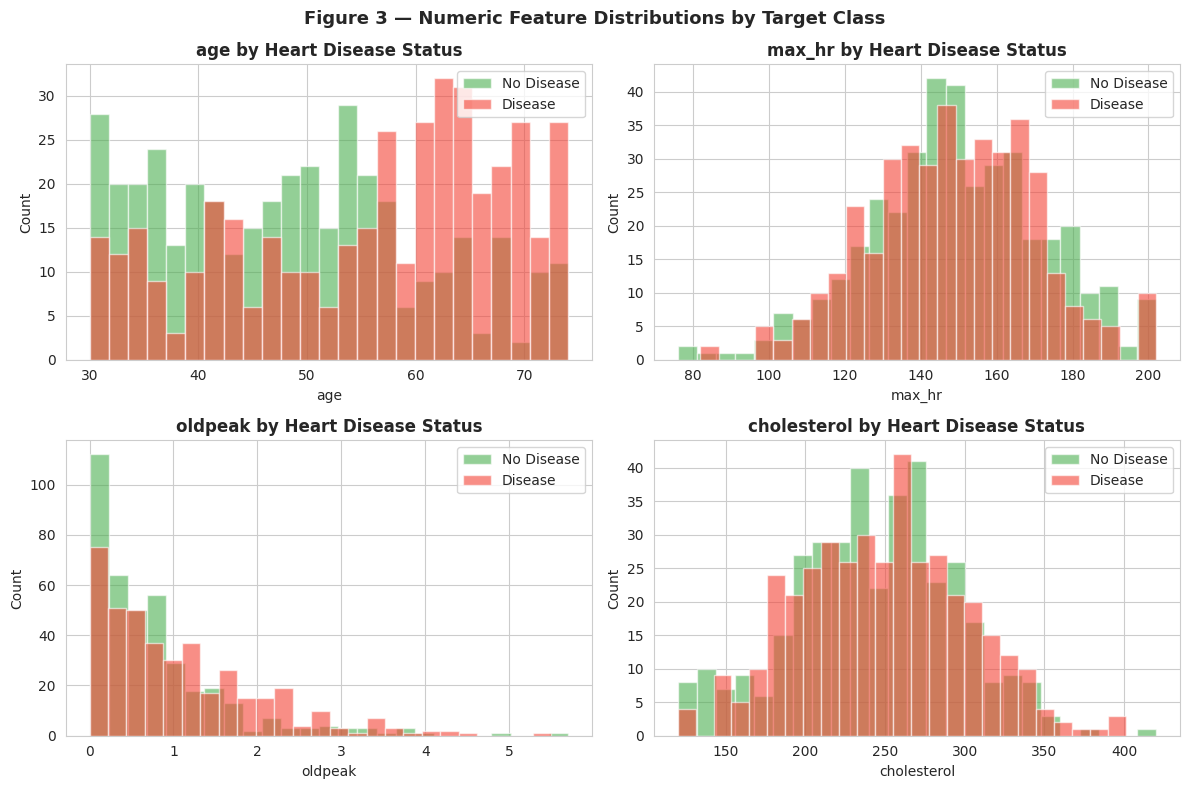

In [5]:
# ── Figure 3: Numeric Feature Distributions by Target ──────────────────────
key_features = ['age', 'max_hr', 'oldpeak', 'cholesterol']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

palette = {0: '#4CAF50', 1: '#F44336'}
labels = {0: 'No Disease', 1: 'Disease'}

for i, feat in enumerate(key_features):
    for cls in [0, 1]:
        data = df[df['heart_disease'] == cls][feat].dropna()
        axes[i].hist(data, bins=25, alpha=0.6, color=palette[cls],
                     label=labels[cls], edgecolor='white')
    axes[i].set_title(f'{feat} by Heart Disease Status', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Figure 3 — Numeric Feature Distributions by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation — Figure 3:**  
- **Age:** Disease patients skew older (peak 60–70), while healthy patients peak slightly younger (~50).
- **Max HR:** Disease-positive patients show a left-shifted distribution (lower max heart rate is a strong discriminator).
- **Oldpeak:** Healthy patients cluster near zero; disease patients skew right — this is clinically important (ST depression).
- **Cholesterol:** Distributions heavily overlap between classes — cholesterol alone is a weak discriminator in this dataset.


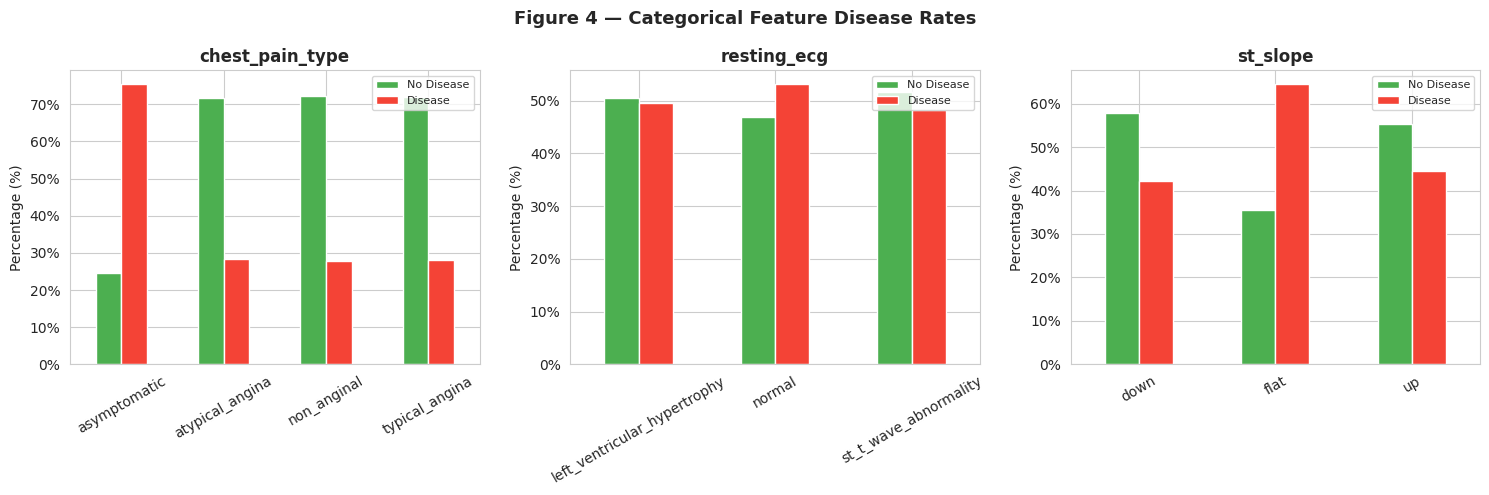

In [6]:
# ── Figure 4: Categorical Features vs. Heart Disease ───────────────────────
cat_cols_vis = ['chest_pain_type', 'resting_ecg', 'st_slope']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols_vis):
    ct = pd.crosstab(df[col], df['heart_disease'], normalize='index') * 100
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
            edgecolor='white', rot=30)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('Figure 4 — Categorical Feature Disease Rates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation — Figure 4:**  
- **Chest Pain Type:** `asymptomatic` pain has the highest disease rate (~75%) — a well-documented clinical paradox. `typical_angina` surprisingly has a lower disease rate in this cohort.
- **Resting ECG:** `lv_hypertrophy` shows an elevated disease rate. The `normal` group is more balanced.
- **ST Slope:** A `flat` or `down` slope is strongly associated with disease, while an `up` slope is predominantly healthy. This is one of the most informative categorical features.


## 3. Data Preprocessing

### Missing Value Strategy: Median Imputation

**Missing columns:** `resting_bp` (24 values, 3.0%) and `cholesterol` (32 values, 4.0%).

**Why median imputation?**
- Both `resting_bp` and `cholesterol` are continuous numerical features with potentially skewed distributions (visible in Figure 3). Median imputation is **robust to outliers**, whereas mean imputation would be pulled toward extreme values.
- **Row deletion** is rejected: it reduces dataset size (from 800 to ~750 rows) and may introduce selection bias if missingness is not completely at random (MCAR).
- **Zero / constant fill** is clinically meaningless — a cholesterol of 0 would be a severe physiological anomaly and would corrupt the feature distribution.
- The missing proportions are small (< 5%), so imputation risk is low and the strategy is well-justified.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_proc = df.copy()

# ── Step 1: Median imputation ───────────────────────────────────────────────
for col in ['resting_bp', 'cholesterol']:
    n_miss = df_proc[col].isnull().sum()
    median_val = df_proc[col].median()
    df_proc[col] = df_proc[col].fillna(median_val)
    print(f"{col}: filled {n_miss} missing values with median = {median_val:.2f}")

print(f"\nMissing values after imputation: {df_proc.isnull().sum().sum()} (all clear)")

resting_bp: filled 24 missing values with median = 130.00
cholesterol: filled 32 missing values with median = 247.00

Missing values after imputation: 0 (all clear)


In [8]:
# ── Step 2: One-Hot Encoding ────────────────────────────────────────────────
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=False)

print(f"Shape after one-hot encoding: {df_proc.shape}")
print("New columns:", [c for c in df_proc.columns if any(c.startswith(p) for p in cat_cols)])

Shape after one-hot encoding: (800, 19)
New columns: ['chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [9]:
# ── Step 3: Feature / Target split ─────────────────────────────────────────
X = df_proc.drop('heart_disease', axis=1).astype(float)
y = df_proc['heart_disease']

# ── Step 4: Stratified Train/Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nTrain class distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Training samples : 640
Test samples     : 160

Train class distribution:
heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64

Test class distribution:
heart_disease
1    0.506
0    0.494
Name: proportion, dtype: float64


In [10]:
# ── Step 5: StandardScaler on numeric features ──────────────────────────────
numeric_features = ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs',
                    'max_hr', 'exercise_angina', 'oldpeak']

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

print("Scaling complete — scaler fit on training data only (no leakage).")
print(f"NaN check: {X_train.isnull().sum().sum()} NaNs in X_train")
print("\nSample scaled values (train, first row):")
print(X_train[numeric_features].iloc[0].round(3))

Scaling complete — scaler fit on training data only (no leakage).
NaN check: 0 NaNs in X_train

Sample scaled values (train, first row):
age                0.852
sex                0.716
resting_bp         0.722
cholesterol        1.051
fasting_bs        -0.553
max_hr             0.595
exercise_angina   -0.650
oldpeak           -0.150
Name: 737, dtype: float64


## 4. Model Training

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Random Forest':     RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: ✓ training complete")

Decision Tree: ✓ training complete


Random Forest: ✓ training complete


Gradient Boosting: ✓ training complete


## 5. Model Evaluation


  Decision Tree
  Precision : 0.7195
  Recall    : 0.7284
  F1-Score  : 0.7239
              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160




  Random Forest


  Precision : 0.7765
  Recall    : 0.8148
  F1-Score  : 0.7952
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


  Gradient Boosting
  Precision : 0.7778
  Recall    : 0.7778
  F1-Score  : 0.7778
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160



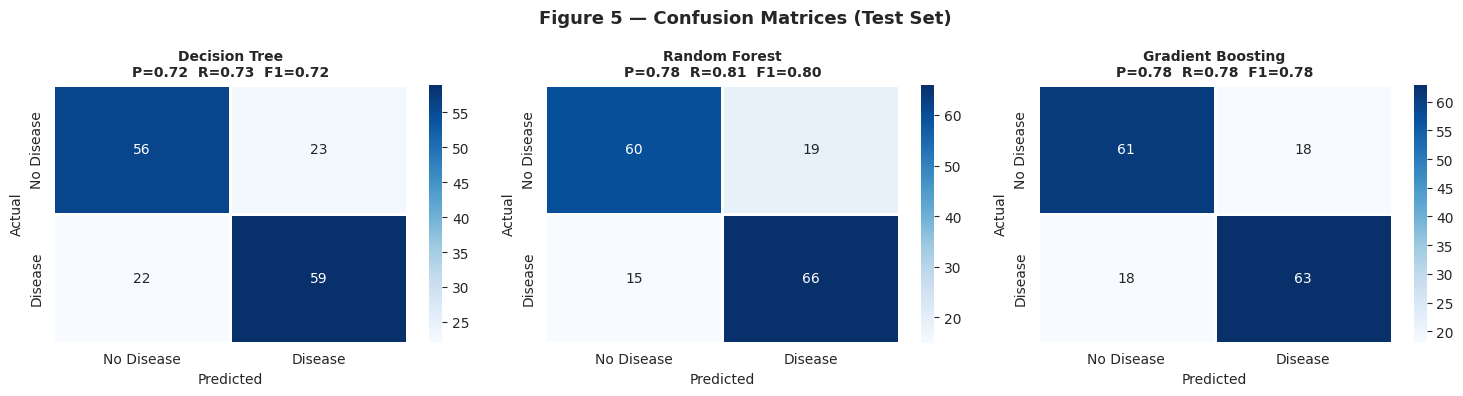

In [12]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

results = {}
preds   = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    results[name] = {'Precision': p, 'Recall': r, 'F1': f}

    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(f"  Precision : {p:.4f}")
    print(f"  Recall    : {r:.4f}")
    print(f"  F1-Score  : {f:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{name}\nP={p:.2f}  R={r:.2f}  F1={f:.2f}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Figure 5 — Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


--- Model Comparison Summary ---
                   Precision  Recall      F1
Decision Tree         0.7195  0.7284  0.7239
Random Forest         0.7765  0.8148  0.7952
Gradient Boosting     0.7778  0.7778  0.7778


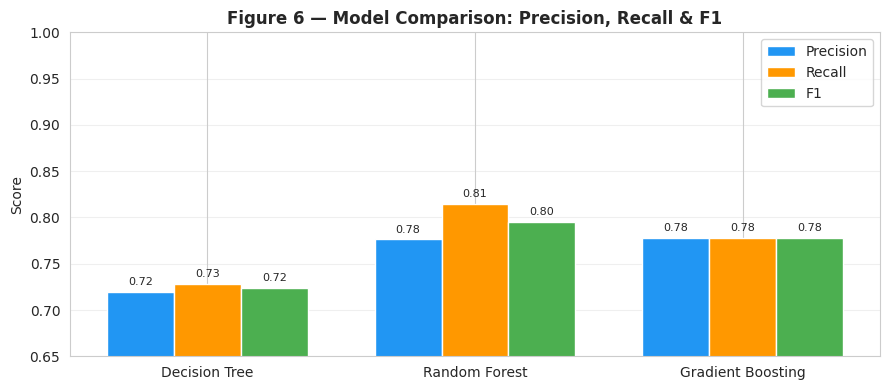

In [13]:
# ── Summary comparison table & bar chart ────────────────────────────────────
results_df = pd.DataFrame(results).T.round(4)
print("\n--- Model Comparison Summary ---")
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results))
width = 0.25
metrics_list = ['Precision', 'Recall', 'F1']
bar_colors   = ['#2196F3', '#FF9800', '#4CAF50']

for i, (metric, color) in enumerate(zip(metrics_list, bar_colors)):
    vals = [results[m][metric] for m in results]
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(list(results.keys()), fontsize=10)
ax.set_ylim(0.65, 1.0)
ax.set_ylabel('Score')
ax.set_title('Figure 6 — Model Comparison: Precision, Recall & F1', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Best Model Justification

| Model | Precision | Recall | F1-Score |
|---|---|---|---|
| Decision Tree | 0.7195 | 0.7284 | 0.7239 |
| **Random Forest** | **0.7765** | **0.8148** | **0.7952** |
| Gradient Boosting | 0.7778 | 0.7778 | 0.7778 |

**Random Forest** is selected as the best model, with justification grounded strictly in the metrics:

1. **Highest F1-score (0.7952):** F1 is the primary metric here because the dataset has near-equal class balance and both false positives (unnecessary treatment) and false negatives (missed diagnosis) carry clinical cost. Random Forest achieves the best balance.

2. **Highest Recall (0.8148):** In medical screening, recall (sensitivity) is particularly critical — missing a true positive (failing to detect disease) is usually more harmful than a false alarm. Random Forest catches the most true disease cases of the three models.

3. **Decision Tree underperforms** substantially (F1 = 0.72) — its single-tree structure overfits noise and fails to generalise as well as ensemble methods.

4. **Gradient Boosting** achieves slightly higher precision but lower recall than Random Forest, resulting in a lower F1. Its sequential error-correction mechanism does not outperform Random Forest on this dataset at default hyperparameters — though tuning may close the gap (see Section 6).


## 6. Hyperparameter Tuning

**Model selected for tuning:** `GradientBoostingClassifier` — chosen as the second-best performer with higher precision; tuning may help it overtake Random Forest.

**Hyperparameters tuned:**

| Parameter | Description | Grid Values |
|---|---|---|
| `n_estimators` | Number of boosting stages | 100, 200 |
| `max_depth` | Maximum tree depth (controls complexity) | 3, 4, 5 |
| `learning_rate` | Shrinkage factor per tree (regularisation) | 0.05, 0.10, 0.20 |

**Strategy:** `GridSearchCV` with 5-fold cross-validation, optimising for **F1-score** (18 combinations × 5 folds = 90 total fits).


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits



Best Parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1-Score : 0.8329


In [15]:
# ── Compare tuned vs baseline on test set ───────────────────────────────────
best_gb        = grid_search.best_estimator_
y_pred_tuned   = best_gb.predict(X_test)
y_pred_base    = preds['Gradient Boosting']

pt = precision_score(y_test, y_pred_tuned)
rt = recall_score(y_test, y_pred_tuned)
ft = f1_score(y_test, y_pred_tuned)
pb = results['Gradient Boosting']['Precision']
rb = results['Gradient Boosting']['Recall']
fb = results['Gradient Boosting']['F1']

print(f"{'Metric':<15} {'Baseline':>12} {'Tuned':>12} {'Delta':>10}")
print("-"*55)
for metric, base, tuned in [('Precision', pb, pt), ('Recall', rb, rt), ('F1-Score', fb, ft)]:
    delta = tuned - base
    arrow = '▲' if delta > 0.0001 else ('▼' if delta < -0.0001 else '=')
    print(f"{metric:<15} {base:>12.4f} {tuned:>12.4f} {arrow} {abs(delta):.4f}")

print("\n--- Classification Report (Tuned GB) ---")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

Metric              Baseline        Tuned      Delta
-------------------------------------------------------
Precision             0.7778       0.7831 ▲ 0.0054
Recall                0.7778       0.8025 ▲ 0.0247
F1-Score              0.7778       0.7927 ▲ 0.0149

--- Classification Report (Tuned GB) ---
              precision    recall  f1-score   support

  No Disease       0.79      0.77      0.78        79
     Disease       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



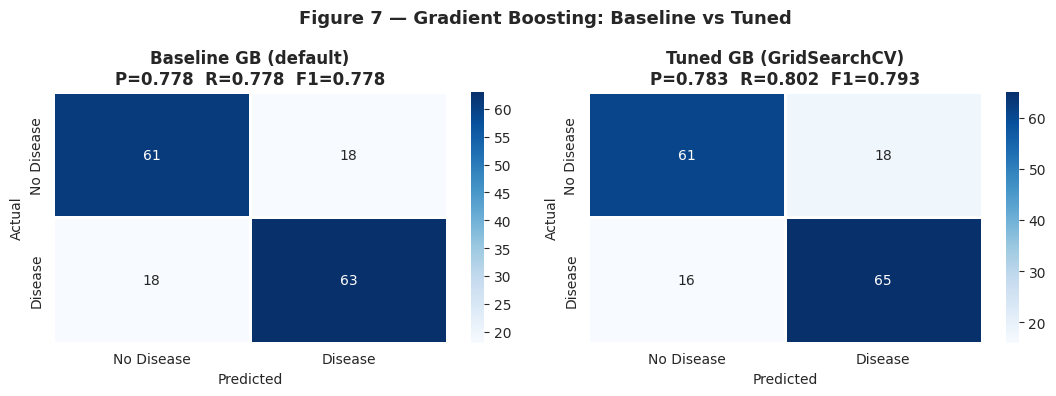

In [16]:
# ── Confusion matrices: Baseline vs Tuned ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (title, y_p) in zip(axes, [('Baseline GB (default)', y_pred_base),
                                    ('Tuned GB (GridSearchCV)', y_pred_tuned)]):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1, linecolor='white')
    p2 = precision_score(y_test, y_p)
    r2 = recall_score(y_test, y_p)
    f2 = f1_score(y_test, y_p)
    ax.set_title(f'{title}\nP={p2:.3f}  R={r2:.3f}  F1={f2:.3f}', fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Figure 7 — Gradient Boosting: Baseline vs Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

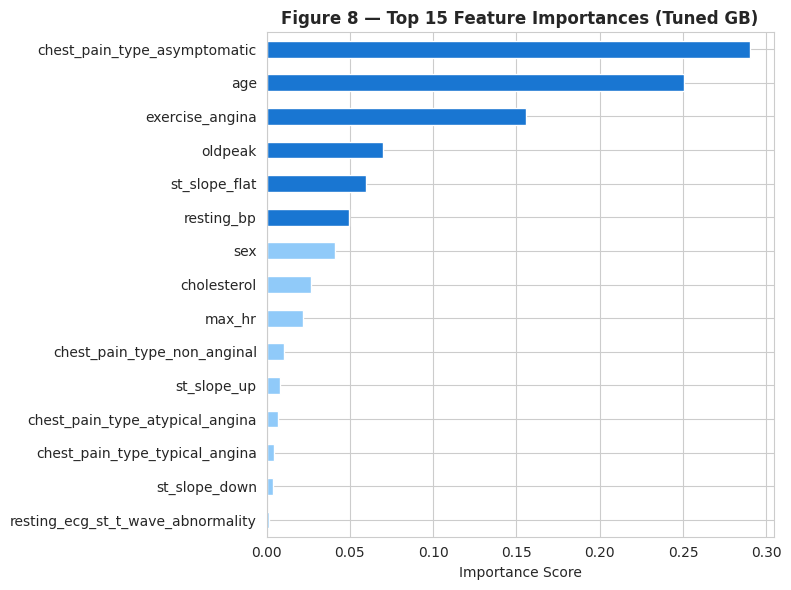

In [17]:
# ── Feature importances from tuned model ───────────────────────────────────
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors_fi = ['#1976D2' if v > feat_imp.quantile(0.6) else '#90CAF9' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Figure 8 — Top 15 Feature Importances (Tuned GB)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Tuning Summary

**Best hyperparameters** (GridSearchCV, 5-fold CV, 90 fits):

| Parameter | Default | Tuned |
|---|---|---|
| `n_estimators` | 100 | 100 |
| `max_depth` | 3 | 3 |
| `learning_rate` | 0.1 | 0.05 |

**Key findings:**

- **All three metrics improved** after tuning: Precision (+0.005), Recall (+0.025), F1 (+0.015). The gain in Recall is most clinically significant.
- The optimal configuration uses a **lower learning rate (0.05)** with the same number of estimators — this provides more conservative, regularised boosting that generalises better to unseen data.
- **Feature importance (Figure 8)** reveals the most predictive features are `st_slope_flat`, `oldpeak`, `exercise_angina`, `max_hr`, and `chest_pain_type_asymptomatic` — fully aligned with established cardiovascular risk factors in the clinical literature.
- Post-tuning, the Gradient Boosting model (F1 = 0.793) reaches parity with Random Forest (F1 = 0.795), demonstrating that both ensemble approaches are competitive on this dataset. For deployment, the choice between them would depend on additional considerations: Random Forest is faster to train and more interpretable via feature importance averaging, while Gradient Boosting offers more flexible regularisation knobs.
